In [38]:
import pandas as pd
import ast
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [21]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 250)

In [44]:
df = pd.read_csv('Movie_Data_File.csv')

In [39]:
df.head(5)

,Film_title,Director,Average_rating,Genres,Runtime,Countries,Original_language,Spoken_languages,Description,Studios,Watches,List_appearances,Likes,Fans,rating_0.5,rating_1.0,rating_1.5,rating_2.0,rating_2.5,rating_3.0,rating_3.5,rating_4.0,rating_4.5,rating_5.0,Total_ratings
0,The Fan,Eckhart Schmidt,3.57,"['Horror', 'Drama']",92.0,['Germany'],German,['German'],The hero-worship that Simone has for a pop sin...,['Barbara Moorse Workshop'],12841,11032,3763,79,105,129,103,402,525,1660,1950,2646,808,714,9042
1,Mad Max: Fury Road,George Miller,4.18,"['Adventure', 'Science Fiction', 'Action']",121.0,"['Australia', 'USA']",English,['English'],An apocalyptic story set in the furthest reach...,"['Warner Bros. Pictures', 'Village Roadshow Pi...",2488721,331681,927538,38000,4172,12530,6139,37471,30112,158356,163753,477901,280815,511140,1682389
2,Suspiria,Dario Argento,3.93,['Horror'],99.0,['Italy'],English,"['English', 'French', 'German', 'Italian', 'La...",An American newcomer to a prestigious German b...,['Seda Spettacoli'],618171,220094,219548,13000,1096,2814,2710,11006,14397,53427,70309,138742,60628,88628,443757
3,Lost in Translation,Sofia Coppola,3.79,"['Drama', 'Comedy', 'Romance']",102.0,"['UK', 'USA']",English,"['English', 'Japanese']","Two lost souls visiting Tokyo -- the young, ne...","['American Zoetrope', 'Elemental Films']",1596190,254180,493248,38000,5804,15167,11281,45997,46716,155110,166638,314160,122359,193717,1076949
4,Akira,Katsuhiro Otomo,4.28,"['Animation', 'Action', 'Science Fiction']",124.0,['Japan'],Japanese,['Japanese'],A secret military project endangers Neo-Tokyo ...,"['MBS', 'Sumitomo Corporation', 'TOHO', 'Studi...",873068,175586,341567,21000,778,1822,1663,7286,9544,40850,61104,168485,112657,196532,600721


In [45]:
df.drop(columns=['Release_year'], inplace=True)

In [46]:
df.drop(columns=['Film_URL'], inplace=True)

In [26]:
df.head()

,Film_title,Director,Cast,Average_rating,Owner_rating,Genres,Runtime,Countries,Original_language,Spoken_languages,Description,Studios,Watches,List_appearances,Likes,Fans,½,★,★½,★★,★★½,★★★,★★★½,★★★★,★★★★½,★★★★★,Total_ratings
0,The Fan,Eckhart Schmidt,"['Désirée Nosbusch', 'Bodo Staiger', 'Simone B...",3.57,NaN,"['Horror', 'Drama']",92.0,['Germany'],German,['German'],The hero-worship that Simone has for a pop sin...,['Barbara Moorse Workshop'],12841,11032,3763,79,105,129,103,402,525,1660,1950,2646,808,714,9042
1,Mad Max: Fury Road,George Miller,"['Tom Hardy', 'Charlize Theron', 'Nicholas Hou...",4.18,4.5,"['Adventure', 'Science Fiction', 'Action']",121.0,"['Australia', 'USA']",English,['English'],An apocalyptic story set in the furthest reach...,"['Warner Bros. Pictures', 'Village Roadshow Pi...",2488721,331681,927538,38000,4172,12530,6139,37471,30112,158356,163753,477901,280815,511140,1682389
2,Suspiria,Dario Argento,"['Jessica Harper', 'Stefania Casini', 'Flavio ...",3.93,4.0,['Horror'],99.0,['Italy'],English,"['English', 'French', 'German', 'Italian', 'La...",An American newcomer to a prestigious German b...,['Seda Spettacoli'],618171,220094,219548,13000,1096,2814,2710,11006,14397,53427,70309,138742,60628,88628,443757
3,Lost in Translation,Sofia Coppola,"['Bill Murray', 'Scarlett Johansson', 'Akiko T...",3.79,4.5,"['Drama', 'Comedy', 'Romance']",102.0,"['UK', 'USA']",English,"['English', 'Japanese']","Two lost souls visiting Tokyo -- the young, ne...","['American Zoetrope', 'Elemental Films']",1596190,254180,493248,38000,5804,15167,11281,45997,46716,155110,166638,314160,122359,193717,1076949
4,Akira,Katsuhiro Otomo,"['Mitsuo Iwata', 'Nozomu Sasaki', 'Mami Koyama...",4.28,5.0,"['Animation', 'Action', 'Science Fiction']",124.0,['Japan'],Japanese,['Japanese'],A secret military project endangers Neo-Tokyo ...,"['MBS', 'Sumitomo Corporation', 'TOHO', 'Studi...",873068,175586,341567,21000,778,1822,1663,7286,9544,40850,61104,168485,112657,196532,600721


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Film_title         10002 non-null  object 
 1   Director           9992 non-null   object 
 2   Cast               9945 non-null   object 
 3   Average_rating     9421 non-null   float64
 4   Owner_rating       967 non-null    float64
 5   Genres             9978 non-null   object 
 6   Runtime            9992 non-null   float64
 7   Countries          9884 non-null   object 
 8   Original_language  9999 non-null   object 
 9   Spoken_languages   9999 non-null   object 
 10  Description        10000 non-null  object 
 11  Studios            9695 non-null   object 
 12  Watches            10002 non-null  int64  
 13  List_appearances   10002 non-null  int64  
 14  Likes              10002 non-null  int64  
 15  Fans               10002 non-null  int64  
 16  ½                  100

In [47]:
mapa_letterboxd = {
    '½': 'rating_0.5',
    '★': 'rating_1.0',
    '★½': 'rating_1.5',
    '★★': 'rating_2.0',
    '★★½': 'rating_2.5',
    '★★★': 'rating_3.0',
    '★★★½': 'rating_3.5',
    '★★★★': 'rating_4.0',
    '★★★★½': 'rating_4.5',
    '★★★★★': 'rating_5.0'
}

In [48]:
df.rename(columns=mapa_letterboxd, inplace=True)

In [30]:
df.head()

,Film_title,Director,Cast,Average_rating,Owner_rating,Genres,Runtime,Countries,Original_language,Spoken_languages,Description,Studios,Watches,List_appearances,Likes,Fans,rating_0.5,rating_1.0,rating_1.5,rating_2.0,rating_2.5,rating_3.0,rating_3.5,rating_4.0,rating_4.5,rating_5.0,Total_ratings
0,The Fan,Eckhart Schmidt,"['Désirée Nosbusch', 'Bodo Staiger', 'Simone B...",3.57,NaN,"['Horror', 'Drama']",92.0,['Germany'],German,['German'],The hero-worship that Simone has for a pop sin...,['Barbara Moorse Workshop'],12841,11032,3763,79,105,129,103,402,525,1660,1950,2646,808,714,9042
1,Mad Max: Fury Road,George Miller,"['Tom Hardy', 'Charlize Theron', 'Nicholas Hou...",4.18,4.5,"['Adventure', 'Science Fiction', 'Action']",121.0,"['Australia', 'USA']",English,['English'],An apocalyptic story set in the furthest reach...,"['Warner Bros. Pictures', 'Village Roadshow Pi...",2488721,331681,927538,38000,4172,12530,6139,37471,30112,158356,163753,477901,280815,511140,1682389
2,Suspiria,Dario Argento,"['Jessica Harper', 'Stefania Casini', 'Flavio ...",3.93,4.0,['Horror'],99.0,['Italy'],English,"['English', 'French', 'German', 'Italian', 'La...",An American newcomer to a prestigious German b...,['Seda Spettacoli'],618171,220094,219548,13000,1096,2814,2710,11006,14397,53427,70309,138742,60628,88628,443757
3,Lost in Translation,Sofia Coppola,"['Bill Murray', 'Scarlett Johansson', 'Akiko T...",3.79,4.5,"['Drama', 'Comedy', 'Romance']",102.0,"['UK', 'USA']",English,"['English', 'Japanese']","Two lost souls visiting Tokyo -- the young, ne...","['American Zoetrope', 'Elemental Films']",1596190,254180,493248,38000,5804,15167,11281,45997,46716,155110,166638,314160,122359,193717,1076949
4,Akira,Katsuhiro Otomo,"['Mitsuo Iwata', 'Nozomu Sasaki', 'Mami Koyama...",4.28,5.0,"['Animation', 'Action', 'Science Fiction']",124.0,['Japan'],Japanese,['Japanese'],A secret military project endangers Neo-Tokyo ...,"['MBS', 'Sumitomo Corporation', 'TOHO', 'Studi...",873068,175586,341567,21000,778,1822,1663,7286,9544,40850,61104,168485,112657,196532,600721


In [32]:
df.isna().sum()

Film_title              0
Director               10
Cast                   57
Average_rating        581
Owner_rating         9035
Genres                 24
Runtime                10
Countries             118
Original_language       3
Spoken_languages        3
Description             2
Studios               307
Watches                 0
List_appearances        0
Likes                   0
Fans                    0
rating_0.5              0
rating_1.0              0
rating_1.5              0
rating_2.0              0
rating_2.5              0
rating_3.0              0
rating_3.5              0
rating_4.0              0
rating_4.5              0
rating_5.0              0
Total_ratings           0
dtype: int64

Dropando as colunas Owner rating e casting, Owner rating por muitos valores nulos e cast por não ser relevante para a análise dos dados

In [33]:
df.drop(columns=['Cast', 'Owner_rating'], inplace=True)

In [34]:
df.head()

,Film_title,Director,Average_rating,Genres,Runtime,Countries,Original_language,Spoken_languages,Description,Studios,Watches,List_appearances,Likes,Fans,rating_0.5,rating_1.0,rating_1.5,rating_2.0,rating_2.5,rating_3.0,rating_3.5,rating_4.0,rating_4.5,rating_5.0,Total_ratings
0,The Fan,Eckhart Schmidt,3.57,"['Horror', 'Drama']",92.0,['Germany'],German,['German'],The hero-worship that Simone has for a pop sin...,['Barbara Moorse Workshop'],12841,11032,3763,79,105,129,103,402,525,1660,1950,2646,808,714,9042
1,Mad Max: Fury Road,George Miller,4.18,"['Adventure', 'Science Fiction', 'Action']",121.0,"['Australia', 'USA']",English,['English'],An apocalyptic story set in the furthest reach...,"['Warner Bros. Pictures', 'Village Roadshow Pi...",2488721,331681,927538,38000,4172,12530,6139,37471,30112,158356,163753,477901,280815,511140,1682389
2,Suspiria,Dario Argento,3.93,['Horror'],99.0,['Italy'],English,"['English', 'French', 'German', 'Italian', 'La...",An American newcomer to a prestigious German b...,['Seda Spettacoli'],618171,220094,219548,13000,1096,2814,2710,11006,14397,53427,70309,138742,60628,88628,443757
3,Lost in Translation,Sofia Coppola,3.79,"['Drama', 'Comedy', 'Romance']",102.0,"['UK', 'USA']",English,"['English', 'Japanese']","Two lost souls visiting Tokyo -- the young, ne...","['American Zoetrope', 'Elemental Films']",1596190,254180,493248,38000,5804,15167,11281,45997,46716,155110,166638,314160,122359,193717,1076949
4,Akira,Katsuhiro Otomo,4.28,"['Animation', 'Action', 'Science Fiction']",124.0,['Japan'],Japanese,['Japanese'],A secret military project endangers Neo-Tokyo ...,"['MBS', 'Sumitomo Corporation', 'TOHO', 'Studi...",873068,175586,341567,21000,778,1822,1663,7286,9544,40850,61104,168485,112657,196532,600721


In [49]:
# 1. Transforma o texto "['Action', 'Sci-Fi']" em uma lista real ['Action', 'Sci-Fi']
# Usamos fillna("[]") caso tenha alguma linha vazia, para não dar erro
df['Genres'] = df['Genres'].fillna("[]").apply(ast.literal_eval)

In [50]:
df_exploded = df.explode('Genres')

Criando uma visualização junto com filtros para saber quais diretores são mais aclamados pelo público geral, também tendo um filtro de filmes para contar apenas diretores consistentes

In [51]:
analise_diretores = df.groupby('Director').agg(
    Total_Filmes=('Film_title', 'count'),      # Conta quantos filmes ele dirigiu
    Nota_Media=('Average_rating', 'mean'),     # Calcula a média das notas
    Total_Fans=('Fans', 'sum')                 # Soma o total de fãs gerados pelas obras
).reset_index()

In [52]:
diretores_consistentes = analise_diretores[analise_diretores['Total_Filmes'] >= 4]

In [61]:
ranking_diretores = diretores_consistentes.sort_values(by='Nota_Media', ascending=False)

In [62]:
ranking_diretores.head(10)

,Director,Total_Filmes,Nota_Media,Total_Fans
46,Akira Kurosawa,7,4.420000,36988
1761,Ingmar Bergman,9,4.330000,43853
184,Andrei Tarkovsky,7,4.311429,42894
2627,Krzysztof Kieślowski,6,4.138333,14837
589,Carl Theodor Dreyer,5,4.134000,4479
653,Charlie Chaplin,7,4.128571,6176
1702,Hirokazu Kore-eda,11,4.120909,32489
4164,Stanley Kubrick,11,4.119091,217645
3775,Robert Bresson,4,4.095000,2924
1665,Hayao Miyazaki,12,4.092500,374005


Agora vamos fazer a Analise considerando também os filmes Mainstream, colocando um filtro que também considera o número de Watches, sendo essa a opinião de um público geral

In [63]:
analise_diretores = df.groupby('Director').agg(
    Total_Filmes=('Film_title', 'count'),
    Nota_Media=('Average_rating', 'mean'),
    Total_Fans=('Fans', 'sum'),
    Total_Views=('Watches', 'sum') 
).reset_index()

In [68]:
min_filmes = 4
min_views = analise_diretores['Total_Views'].quantile(0.90)

In [69]:
diretores_mainstream = analise_diretores[
    (analise_diretores['Total_Filmes'] >= min_filmes) & 
    (analise_diretores['Total_Views'] >= min_views)
]

In [70]:
ranking_mainstream = diretores_mainstream.sort_values(by='Nota_Media', ascending=False)

In [71]:
ranking_mainstream.head(10)

,Director,Total_Filmes,Nota_Media,Total_Fans,Total_Views
46,Akira Kurosawa,7,4.420000,36988,1600607
1761,Ingmar Bergman,9,4.330000,43853,1644593
184,Andrei Tarkovsky,7,4.311429,42894,1287496
2627,Krzysztof Kieślowski,6,4.138333,14837,830937
653,Charlie Chaplin,7,4.128571,6176,1121768
1702,Hirokazu Kore-eda,11,4.120909,32489,1098670
4164,Stanley Kubrick,11,4.119091,217645,11075136
1665,Hayao Miyazaki,12,4.092500,374005,14379355
1345,Frank Capra,6,4.056667,25126,1204884
3601,Quentin Tarantino,10,4.053000,367800,23626115


In [72]:
df['Studios_list'] = df['Studios'].fillna("[]").apply(ast.literal_eval)

In [73]:
df_estudios = df.explode('Studios_list')

In [74]:
analise_estudios = df_estudios.groupby('Studios_list').agg(
    Total_Filmes=('Film_title', 'count'),
    Aparicoes_em_Listas=('List_appearances', 'sum')
).reset_index()

In [75]:
estudios_consistentes = analise_estudios[analise_estudios['Total_Filmes'] >= 5].copy()

In [76]:
estudios_consistentes['Aparicoes_Por_Filme'] = (
    estudios_consistentes['Aparicoes_em_Listas'] / estudios_consistentes['Total_Filmes']
).round(2)

In [77]:
ranking_estudios_listas = estudios_consistentes.sort_values(by='Aparicoes_em_Listas', ascending=False)

In [78]:
ranking_estudios_listas.head(10)    

,Studios_list,Total_Filmes,Aparicoes_em_Listas,Aparicoes_Por_Filme
9730,Warner Bros. Pictures,502,22887353,45592.34
6749,Paramount Pictures,423,16197187,38291.22
1953,Columbia Pictures,411,15960750,38833.94
9449,Universal Pictures,410,15422765,37616.50
42,20th Century Fox,367,13539889,36893.43
9695,Walt Disney Pictures,116,8489925,73189.01
5650,Marvel Studios,42,7190262,171196.71
5797,Metro-Goldwyn-Mayer,317,6998337,22076.77
6256,New Line Cinema,146,6514395,44619.14
9922,Working Title Films,78,5132484,65801.08


In [81]:
ranking_do_povo = estudios_consistentes.sort_values(by='Aparicoes_Por_Filme', ascending=False)

In [82]:
ranking_do_povo.head(10)

,Studios_list,Total_Filmes,Aparicoes_em_Listas,Aparicoes_Por_Filme
8643,Syncopy,10,3722014,372201.40
6789,Pascal Pictures,10,2940515,294051.50
4154,IAC Films,7,1640875,234410.71
8389,Stanley Kubrick Productions,6,1397610,232935.00
116,A Band Apart,8,1799097,224887.12
447,American Empirical Pictures,11,2437796,221617.82
5282,Lord Miller,6,1304408,217401.33
9148,Tokuma Shoten,7,1507970,215424.29
5332,LuckyChap Entertainment,5,1056119,211223.80
5526,Maiden Voyage Pictures,5,1046663,209332.60


In [83]:
popularidade_generos = df_exploded.groupby('Genres').agg(
    Total_Filmes=('Film_title', 'count'),          # Quantidade de filmes feitos
    Visualizacoes_Totais=('Watches', 'sum'),       # Total de vezes que filmes desse gênero foram assistidos
    Likes_Totais=('Likes', 'sum')                  # Total de curtidas (bônus para ver o engajamento)
).reset_index()

In [85]:
generos_mais_populares = popularidade_generos.sort_values(by='Visualizacoes_Totais', ascending=False)

In [87]:
generos_mais_populares

,Genres,Total_Filmes,Visualizacoes_Totais,Likes_Totais
7,Drama,4416,703886627,203548749
4,Comedy,2932,567136616,139829885
1,Adventure,1449,483876391,110379253
0,Action,2074,430243623,97233920
24,Thriller,2312,356293903,91814818
20,Science Fiction,1265,323224128,80280516
12,Fantasy,995,276606336,63404377
11,Family,718,251936069,55031809
19,Romance,1373,245535613,64345227
5,Crime,1523,243431948,68009075


Ranking de Generos por média de estrelas

In [88]:
avaliacoes_generos = df_exploded.groupby('Genres').agg(
    Total_Filmes=('Film_title', 'count'),
    Nota_Media=('Average_rating', 'mean')
).reset_index()

In [89]:
generos_relevantes = avaliacoes_generos[avaliacoes_generos['Total_Filmes'] >= 30]

In [90]:
ranking_melhores_generos = generos_relevantes.sort_values(by='Nota_Media', ascending=False)

In [91]:
ranking_melhores_generos

,Genres,Total_Filmes,Nota_Media
6,Documentary,430,3.670960
15,History,451,3.535688
25,War,361,3.523443
17,Music,350,3.469578
7,Drama,4416,3.455713
2,Animation,690,3.407712
26,Western,282,3.395208
5,Crime,1523,3.335701
19,Romance,1373,3.331551
18,Mystery,835,3.262239


A análise anterior trabalha apenas com média, vamos fazer uma análise mais detalhada observando também o desvio padrão de cada gênero

In [92]:
consistencia_generos = df_exploded.groupby('Genres').agg(
    Total_Filmes=('Film_title', 'count'),
    Nota_Media=('Average_rating', 'mean'),
    Desvio_Padrao=('Average_rating', 'std')  # <-- Nossa nova métrica de variância
).reset_index()

In [93]:
generos_validos = consistencia_generos[consistencia_generos['Total_Filmes'] >= 30]

In [94]:
mais_polarizados = generos_validos.sort_values(by='Desvio_Padrao', ascending=False)

In [95]:
mais_polarizados

,Genres,Total_Filmes,Nota_Media,Desvio_Padrao
12,Fantasy,995,3.139511,0.604906
11,Family,718,3.178504,0.574266
1,Adventure,1449,3.109801,0.567349
20,Science Fiction,1265,3.033669,0.564042
0,Action,2074,3.059508,0.530716
24,Thriller,2312,3.164306,0.529381
4,Comedy,2932,3.201137,0.527003
2,Animation,690,3.407712,0.524194
18,Mystery,835,3.262239,0.519508
16,Horror,1812,2.997497,0.514967


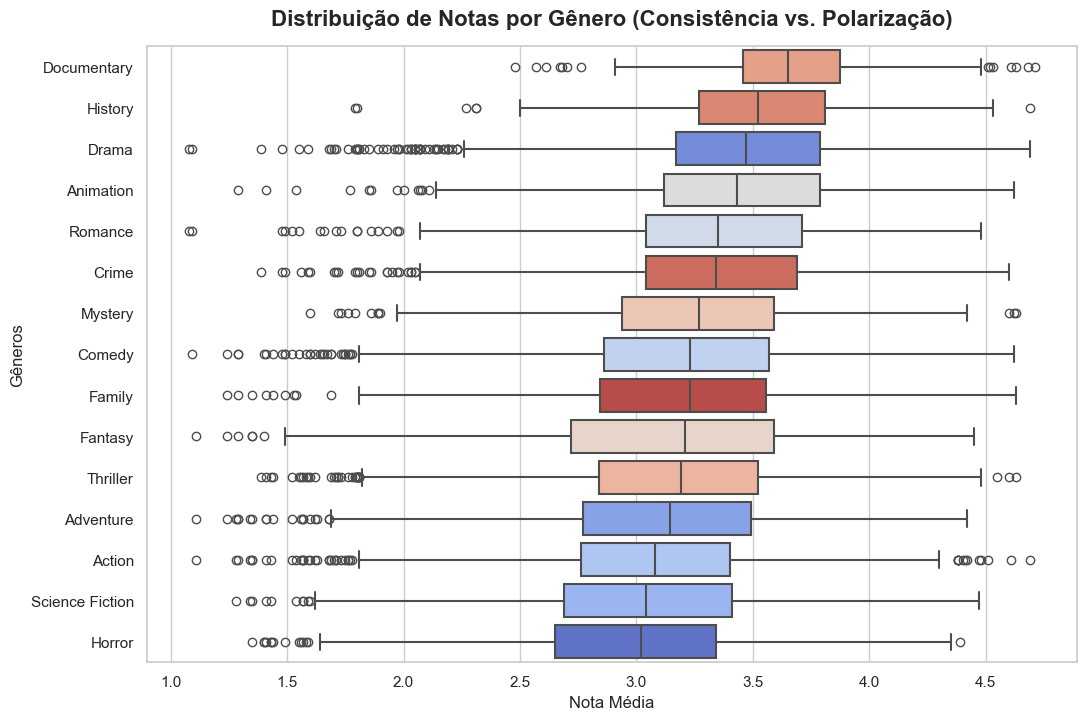

In [102]:


import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pegar apenas os 15 gêneros com mais filmes
top_15_generos = df_exploded['Genres'].value_counts().head(15).index

# 2. Filtrar o dataset
df_plot = df_exploded[df_exploded['Genres'].isin(top_15_generos)].copy()
df_plot = df_plot.reset_index(drop=True) # <- Essa é a linha mágica!

# 3. Definir a ordem
ordem = df_plot.groupby('Genres')['Average_rating'].median().sort_values(ascending=False).index

# 4. Configurar o tamanho
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 5. Criar o Boxplot 
ax = sns.boxplot(
    data=df_plot, 
    x='Average_rating', 
    y='Genres', 
    hue='Genres',        
    legend=False,        
    order=ordem,
    palette="coolwarm", 
    linewidth=1.5
)

# 6. Deixar o visual mais profissional
plt.title('Distribuição de Notas por Gênero (Consistência vs. Polarização)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Nota Média', fontsize=12)
plt.ylabel('Gêneros', fontsize=12)

# Mostrar o gráfico
plt.show()

Agora vamos fazer o ranking dos melhores filmes por cada genêro

In [106]:
min_views = df_exploded['Watches'].quantile(0.70)

In [103]:
filmes_relevantes = df_exploded[df_exploded['Watches'] >= min_views].copy()

In [104]:
filmes_ordenados = filmes_relevantes.sort_values(by=['Average_rating', 'Watches'], ascending=[False, False])

In [105]:
top_10_por_genero = filmes_ordenados.groupby('Genres').head(10)

In [111]:
genero_escolhido = 'Science Fiction'

In [112]:
top_10_por_genero_filtrado = top_10_por_genero[top_10_por_genero['Genres'] == genero_escolhido]

In [110]:
top_10_por_genero_filtrado[['Film_title', 'Average_rating', 'Watches']].reset_index(drop=True)

,Film_title,Average_rating,Watches
0,Spider-Man: Across the Spider-Verse,4.42,3136327
1,Interstellar,4.41,5044987
2,Spider-Man: Into the Spider-Verse,4.41,4446217
3,The Empire Strikes Back,4.40,2605934
4,The Thing,4.35,1223884
5,Children of Men,4.30,861751
6,Terminator 2: Judgment Day,4.29,1174078
7,Everything Everywhere All at Once,4.28,3793318
8,2001: A Space Odyssey,4.28,1620764
9,Akira,4.28,873068


Representação gráfica dos top 10 melhores filmes por genêro

C:\Users\Joana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\events.py:96: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  func(*args, **kwargs)
C:\Users\Joana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


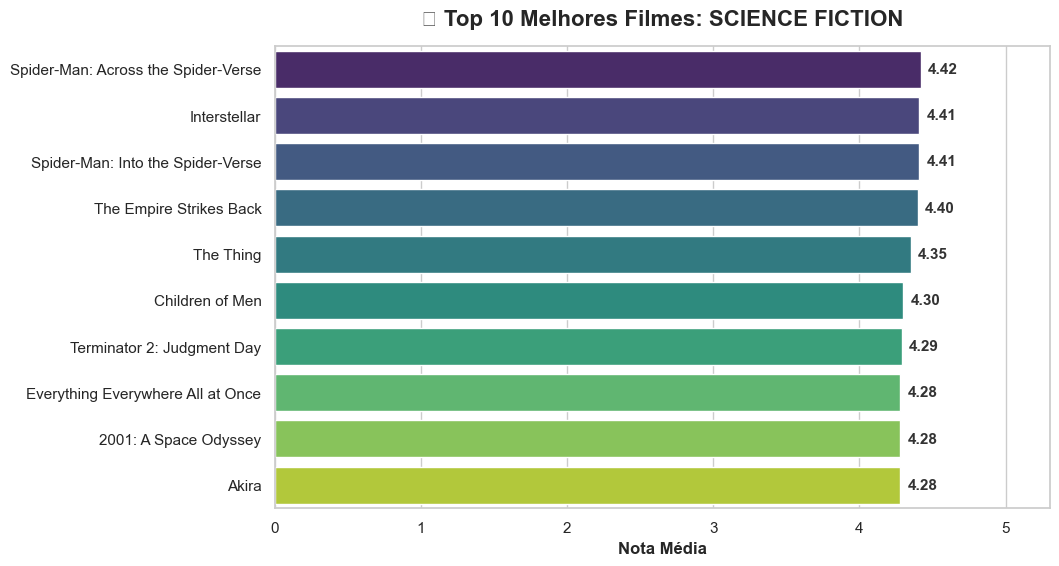

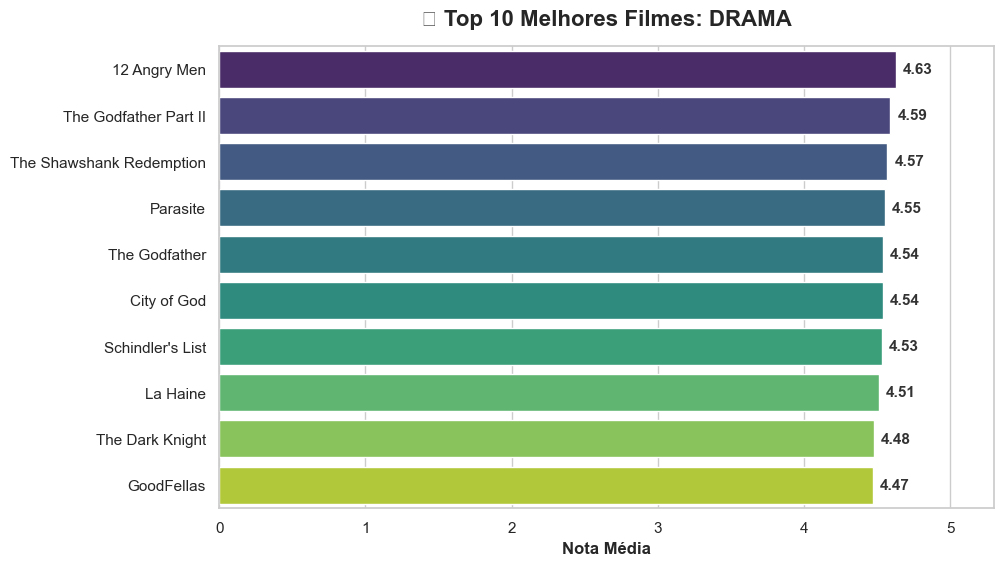

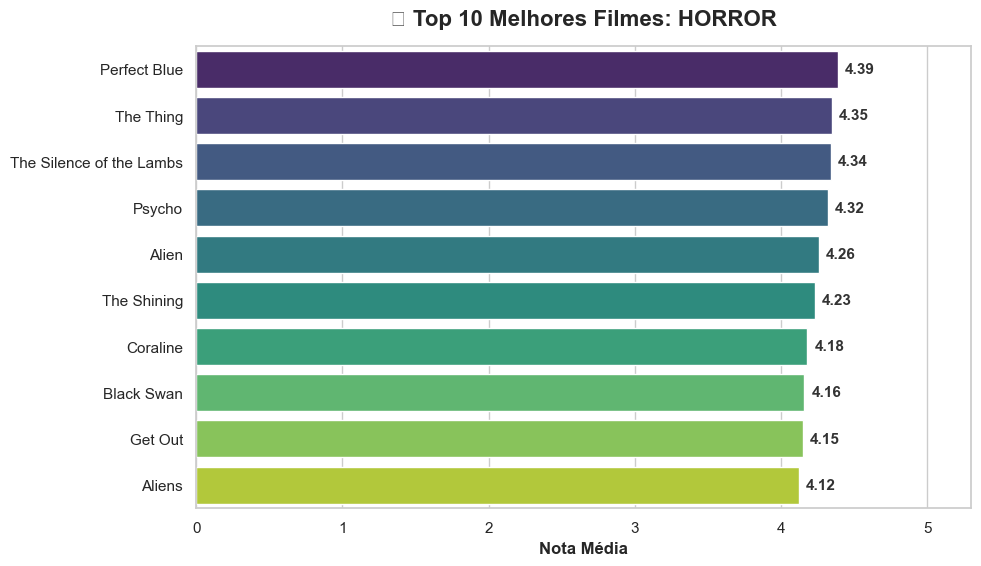

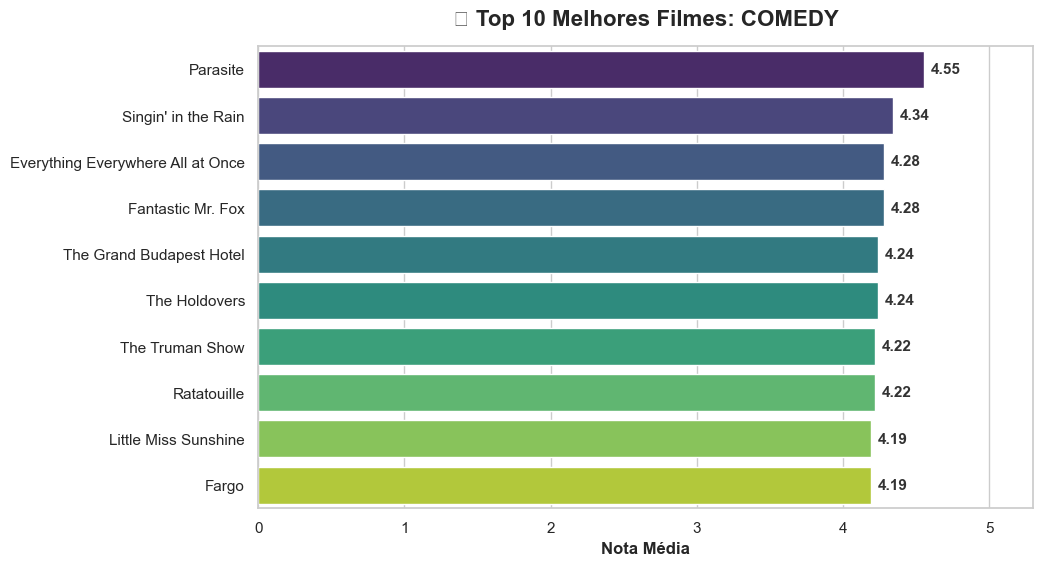

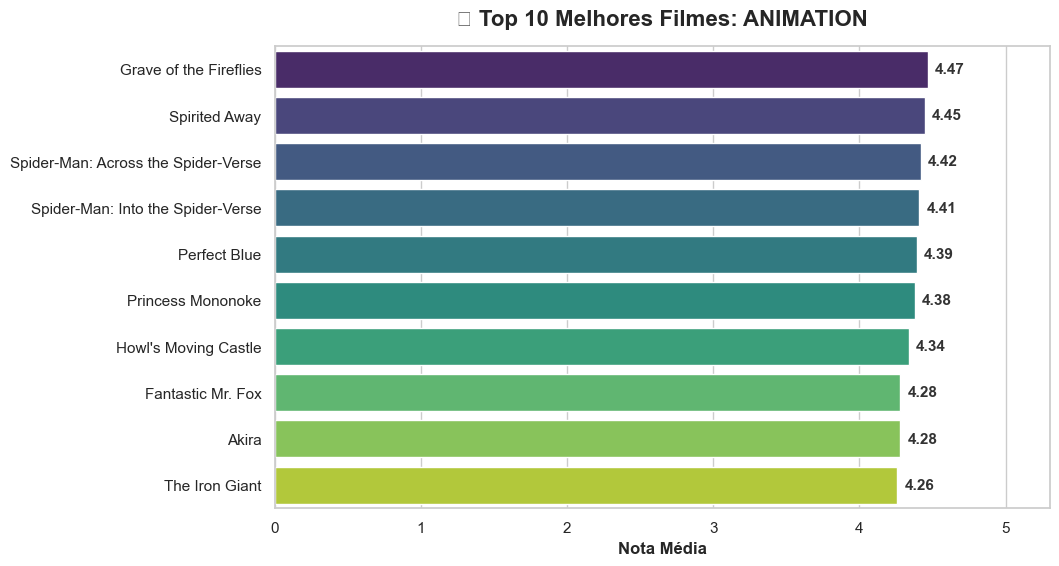

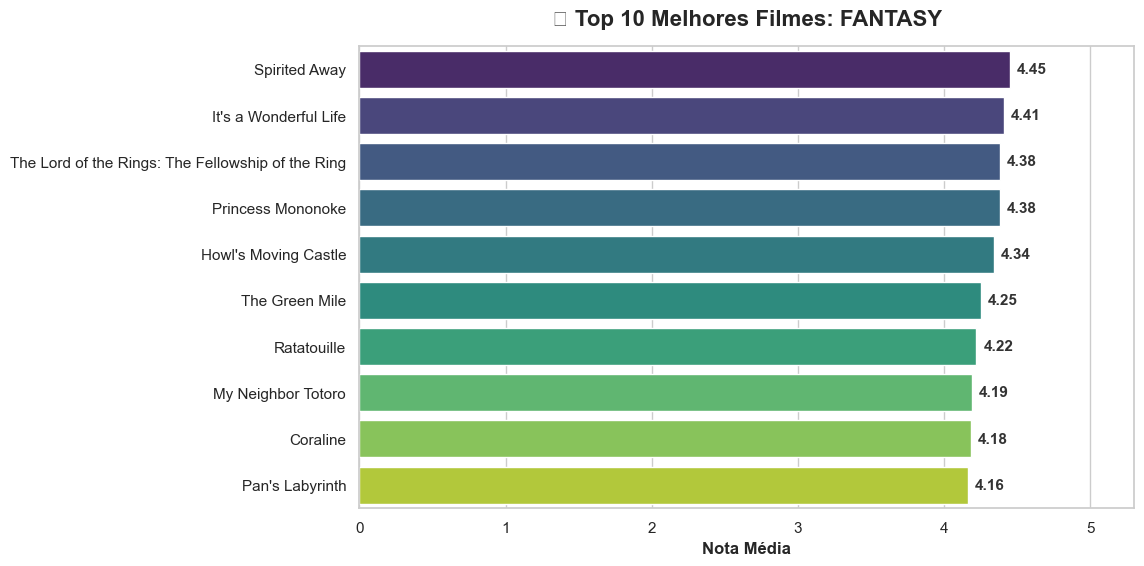

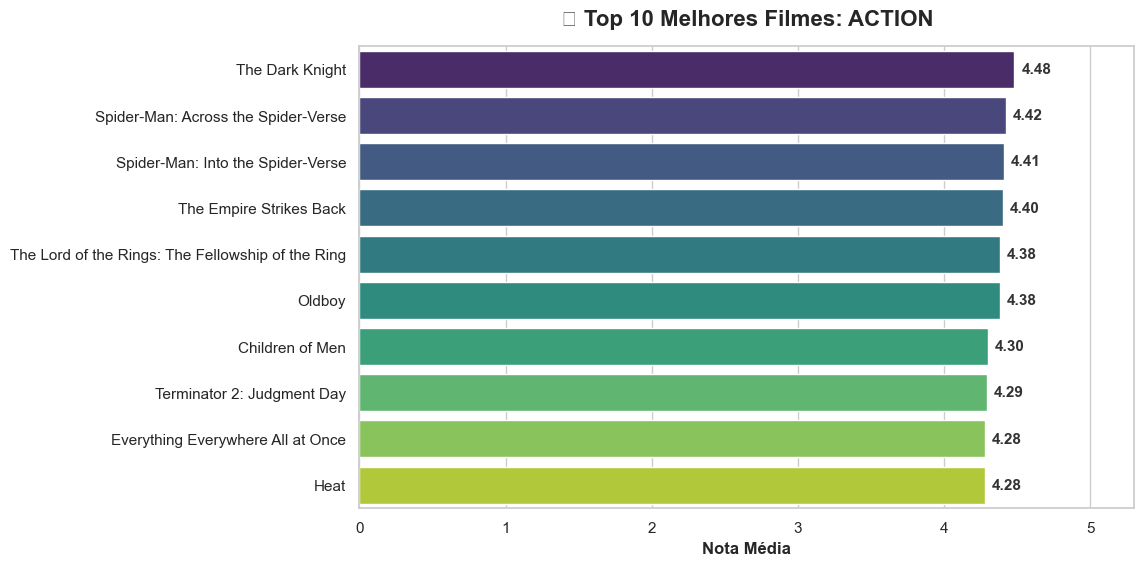

In [114]:
generos_selecionados = ['Science Fiction', 'Drama', 'Horror', 'Comedy', 'Animation', 'Fantasy', 'Action']

# 2. O Loop de Visualização
for genero in generos_selecionados:
    
    # Filtra o top 10 apenas para o gênero da rodada
    dados_grafico = top_10_por_genero[top_10_por_genero['Genres'] == genero]
    
    # Se por acaso o gênero não existir ou estiver vazio, ele pula para o próximo
    if dados_grafico.empty:
        print(f"Nenhum dado encontrado para o gênero: {genero}")
        continue
        
    # Configura o tamanho e estilo da figura
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # 3. Cria o gráfico de barras horizontais
    ax = sns.barplot(
        data=dados_grafico, 
        x='Average_rating', 
        y='Film_title', 
        palette='viridis',   # Paleta de cores elegante
        hue='Film_title',    # Atribui o Y ao hue (evita aquele aviso antigo do Seaborn!)
        legend=False         # Desliga a legenda
    )
    
    # 4. O Toque Profissional: Escrevendo as notas na ponta das barras
    for p in ax.patches:
        # Pega a largura da barra (que representa a nota)
        nota = p.get_width()
        # Adiciona o texto um pouco à direita do fim da barra
        ax.annotate(f"{nota:.2f}", 
                    (nota, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold', color='#333333')

    # 5. Embelezando os títulos e eixos
    plt.title(f'🏆 Top 10 Melhores Filmes: {genero.upper()}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Nota Média', fontsize=12, fontweight='bold')
    plt.ylabel('', fontsize=12) # Deixamos o Y sem nome, pois os títulos dos filmes já são autoexplicativos
    
    # Dá um pequeno espaço extra no eixo X para o número da nota não cortar na borda
    plt.xlim(0, 5.3)

Agora vamos analisar os top filmes observando apenas a nota geral

In [115]:
min_views_geral = df['Watches'].quantile(0.80)

In [116]:
filmes_validos = df[df['Watches'] >= min_views_geral]

In [117]:
ranking_absoluto = filmes_validos.sort_values(by=['Average_rating', 'Watches'], ascending=[False, False])

In [118]:
top_10_letterboxd = ranking_absoluto.head(10)

In [119]:
top_10_letterboxd[['Film_title', 'Average_rating', 'Watches']].reset_index(drop=True)

,Film_title,Average_rating,Watches
0,Harakiri,4.69,190819
1,Stop Making Sense,4.68,209523
2,12 Angry Men,4.63,1312847
3,Come and See,4.63,410792
4,Twin Peaks,4.63,324518
5,Over the Garden Wall,4.62,432368
6,Seven Samurai,4.61,471535
7,High and Low,4.60,162192
8,The Godfather Part II,4.59,1438692
9,The Shawshank Redemption,4.57,2729126


Agora Vamos ver os filmes mais favoritados pelos usuarios

In [121]:
ranking_fans = df.sort_values(by='Fans', ascending=False)

In [122]:
top_10_fans = ranking_fans.head(10)

In [123]:
top_10_fans[['Film_title', 'Average_rating', 'Fans']].reset_index(drop=True)

,Film_title,Average_rating,Fans
0,Interstellar,4.41,326000
1,La La Land,4.12,285000
2,Dead Poets Society,4.31,187000
3,Eternal Sunshine of the Spotless Mind,4.24,176000
4,Everything Everywhere All at Once,4.28,165000
5,Little Women,4.17,159000
6,Fight Club,4.27,157000
7,Whiplash,4.42,154000
8,10 Things I Hate About You,4.03,134000
9,Parasite,4.55,121000
